In [1]:
#Calculate the avg marks and print class failed or passed is the avg is 50 or above
marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")

print("Average:", average)

Class failed
Average: 43.0


In [2]:
import pandas as pd
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

print(df)

   student_id  attendance_percent  assignment_score  quiz_score  lab_completed
0         101                  92                18          72           True
1         102                  67                12          48          False
2         103                  81                15          65           True
3         104                  45                 8          30          False
4         105                  74                14          55           True
5         106                  88                19          80           True


In [3]:
df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [4]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
print(df)

   student_id  attendance_percent  assignment_score  quiz_score  \
0         101                  92                18          72   
1         102                  67                12          48   
2         103                  81                15          65   
3         104                  45                 8          30   
4         105                  74                14          55   
5         106                  88                19          80   

   lab_completed  total_score  
0           True           90  
1          False           60  
2           True           80  
3          False           38  
4           True           69  
5           True           99  


In [5]:
df['Eligible'] =( (df['attendance_percent'] >= 75) &
(df['total_score'] >= 70) &
(df['lab_completed'])
)
print(df)

   student_id  attendance_percent  assignment_score  quiz_score  \
0         101                  92                18          72   
1         102                  67                12          48   
2         103                  81                15          65   
3         104                  45                 8          30   
4         105                  74                14          55   
5         106                  88                19          80   

   lab_completed  total_score  Eligible  
0           True           90      True  
1          False           60     False  
2           True           80      True  
3          False           38     False  
4           True           69     False  
5           True           99      True  


In [6]:
eligible_student = df[df['Eligible']==True]
eligible_student

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,Eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


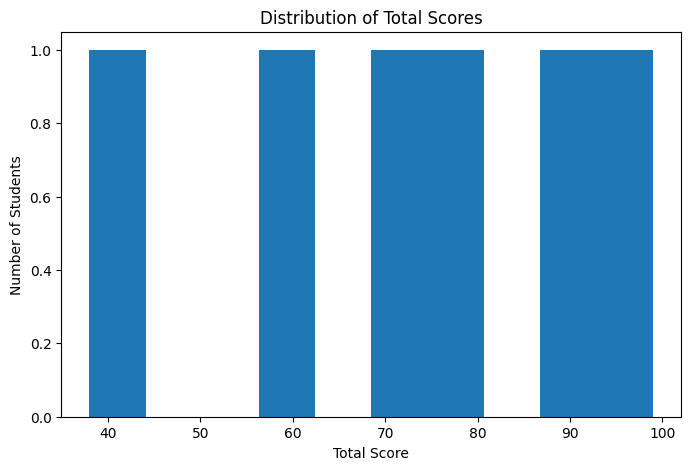

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Redefine df and total_score for self-contained execution if previous cells weren't run
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}
df = pd.DataFrame(data)
df['total_score'] = df['assignment_score'] + df['quiz_score']

# Total Score Distribution
plt.figure(figsize=(8,5))
plt.hist(df['total_score'], bins=10)
plt.title('Distribution of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Number of Students')
plt.show()

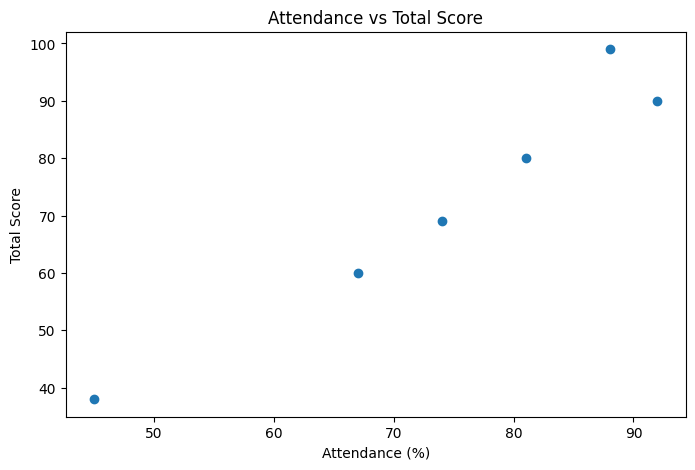

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df['attendance_percent'],
            df['total_score'])
plt.title('Attendance vs Total Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Total Score')
plt.show()

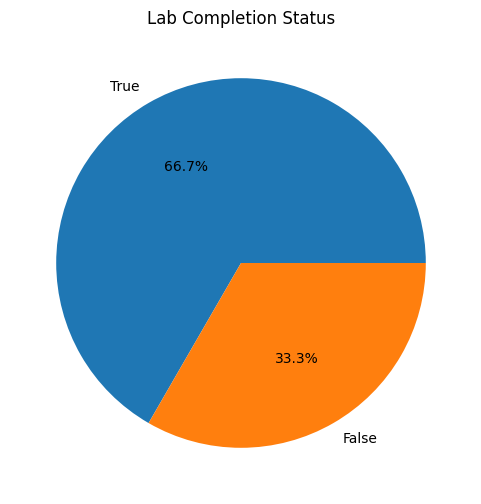

In [9]:
import matplotlib.pyplot as plt

lab_counts = df['lab_completed'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    lab_counts,
    labels=lab_counts.index,
    autopct='%1.1f%%'
)

plt.title('Lab Completion Status')
plt.show()